<a href="https://colab.research.google.com/github/hanyat48/RVC-d-s/blob/main/RVC_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Model 1.1
Swin-UNET – Uses Swin Transformer blocks (shifted window attention)


In [ ]:
# !pip install torch torchvision monai nibabel pillow tqdm matplotlib
!pip install pynrrd
# !pip install monai torch torchvision matplotlib tqdm scikit-learn

In [ ]:
import os
import glob
import numpy as np
from PIL import Image
import nrrd  # for reading .nrrd files

# ==== PATHS ====
IMG_DIR = "/content/drive/MyDrive/RVC- Fracture Detection DP/DP"
MASK_DIR = "/content/drive/MyDrive/RVC- Fracture Detection DP/DP Seg"

# ==== LOAD FILENAMES ====
image_files = sorted(glob.glob(os.path.join(IMG_DIR, "*.png")))
mask_files = sorted(glob.glob(os.path.join(MASK_DIR, "*.nrrd")))

mask_dict = {
    os.path.splitext(os.path.basename(f))[0].replace("Seg", ""): f
    for f in mask_files
}

# ==== TARGET SHAPE ====
TARGET_SIZE = (512, 512)

images_np = []
masks_np = []
labels_np = []

for img_path in image_files:
    base = os.path.splitext(os.path.basename(img_path))[0]
    # print(base)

    # --- Load and resize image ---
    img = Image.open(img_path).convert("L")  # grayscale
    img = img.resize(TARGET_SIZE, Image.BILINEAR)
    img_np = np.array(img, dtype=np.float32) / 255.0  # normalize to [0, 1]

    # --- Load and resize mask if exists ---
    if base in mask_dict:
        mask_path = mask_dict[base]
        mask_np, _ = nrrd.read(mask_path)
        mask_np = np.squeeze(mask_np)  # remove singleton dims
        mask_np = mask_np.astype(np.float32)

        # Ensure it’s 2D before resizing
        if mask_np.ndim != 2:
            mask_np = mask_np[..., 0]  # take first slice if needed

        mask_img = Image.fromarray(mask_np)
        mask_img = mask_img.resize(TARGET_SIZE, Image.NEAREST)
        mask_np = np.array(mask_img, dtype=np.float32)

        label = 1  # fractured
    else:
        mask_np = np.zeros(TARGET_SIZE, dtype=np.float32)
        label = 0  # healthy
        # print(base)

    images_np.append(img_np)
    masks_np.append(mask_np)
    labels_np.append(label)

# ==== Convert to numpy arrays ====
images_np = np.stack(images_np, axis=0)
masks_np = np.stack(masks_np, axis=0)
labels_np = np.array(labels_np, dtype=np.int32)

print(f"✅ Loaded {len(images_np)} samples")
print(f"Images: {images_np.shape} | Masks: {masks_np.shape} | Labels: {labels_np.shape}")
print(f"Fractured: {np.sum(labels_np)} | Healthy: {len(labels_np) - np.sum(labels_np)}")


✅ Loaded 112 samples
Images: (112, 512, 512) | Masks: (112, 512, 512) | Labels: (112,)
Fractured: 49 | Healthy: 63


✅ Dataset ready — 78 train, 34 val samples


Epoch 1/30: 100%|██████████| 39/39 [00:13<00:00,  2.96it/s]


Epoch 1/30 | Train Loss: 1.4138 | Dice: 0.0001 | IoU: 0.0000
✅ Saved new best model


Epoch 2/30: 100%|██████████| 39/39 [00:11<00:00,  3.37it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Jaccard is ill-defined and being set to 0.0 due to no true or predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Jaccard is ill-defined and being set to 0.0 due to no true or predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Jaccard is ill-defined and being set to 0.0 due to no true or predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(resu

Epoch 2/30 | Train Loss: 1.2288 | Dice: 0.0000 | IoU: 0.0000


...

Epoch 29/30 | Train Loss: 0.9947 | Dice: 0.0001 | IoU: 0.0001


Epoch 30/30: 100%|██████████| 39/39 [00:11<00:00,  3.34it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Jaccard is ill-defined and being set to 0.0 due to no true or predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 30/30 | Train Loss: 0.9950 | Dice: 0.0049 | IoU: 0.0027
🏁 Training done. Best Dice: 0.0109


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Jaccard is ill-defined and being set to 0.0 due to no true or predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Jaccard is ill-defined and being set to 0.0 due to no true or predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


✅ Final Validation Dice: 0.0109
✅ Final Validation IoU:  0.0059


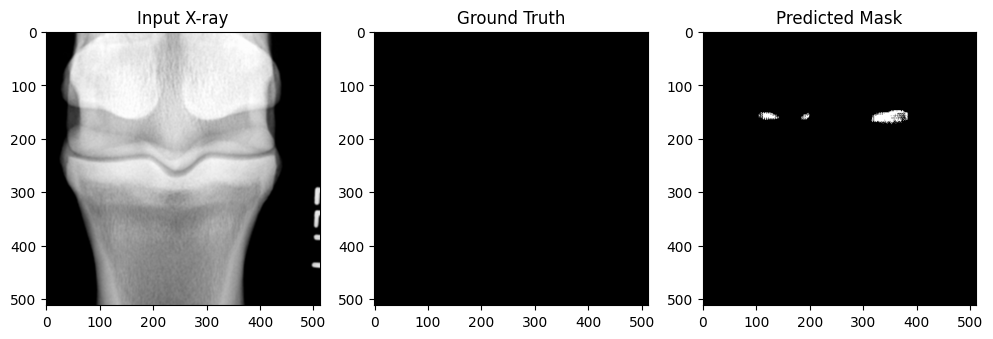

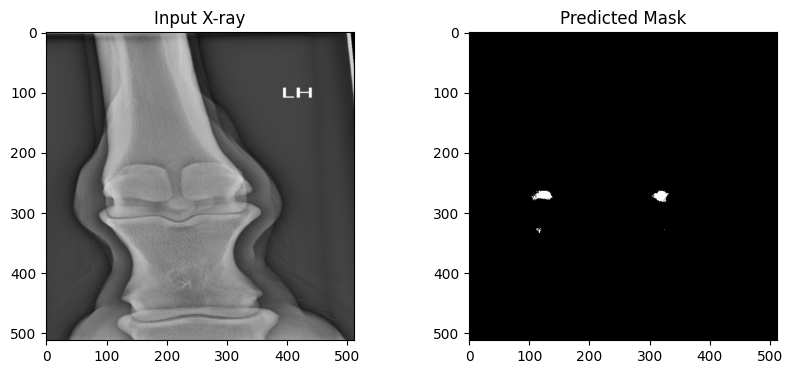

In [ ]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn as nn
import torch.optim as optim
from monai.networks.nets import SwinUNETR
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import jaccard_score

# ======== DATASET CLASS ========
class FractureDataset(Dataset):
    def __init__(self, images_np, masks_np):
        self.images = images_np
        self.masks = masks_np

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        mask = self.masks[idx]

        # Normalize and add channel dim
        img = torch.tensor(img, dtype=torch.float32).unsqueeze(0)
        mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)

        return img, mask

# ======== CONFIG ========
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE = 512
BATCH_SIZE = 2
EPOCHS = 30
LR = 1e-4

# ======== SPLIT DATA ========
dataset = FractureDataset(images_np, masks_np)
train_size = int(0.7 * len(dataset))
val_size = len(dataset) - train_size
train_set, val_set = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_set, batch_size=1)

print(f"✅ Dataset ready — {train_size} train, {val_size} val samples")

# ======== MODEL ========
model = SwinUNETR(
    spatial_dims=2,        # for 2D X-ray images
    in_channels=1,
    out_channels=1,
    feature_size=48,
    use_checkpoint=False
).to(DEVICE)

criterion = DiceCELoss(sigmoid=True, squared_pred=True)
optimizer = optim.AdamW(model.parameters(), lr=LR)
dice_metric = DiceMetric(include_background=False, reduction="mean")

# ======== TRAIN LOOP ========
best_dice = 0
for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    for imgs, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)

        optimizer.zero_grad()
        preds = model(imgs)
        loss = criterion(preds, masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # ===== Validation =====
    model.eval()
    dices, ious = [], []
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            outputs = torch.sigmoid(model(imgs))
            preds = (outputs > 0.5).float()

            dice_metric(preds, masks)
            dice_val = dice_metric.aggregate().item()
            dice_metric.reset()

            preds_np = preds.cpu().numpy().flatten()
            masks_np = masks.cpu().numpy().flatten()
            iou_val = jaccard_score(masks_np, preds_np, average='binary')

            dices.append(dice_val)
            ious.append(iou_val)

    val_dice = np.mean(dices)
    val_iou = np.mean(ious)
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss/len(train_loader):.4f} | Dice: {val_dice:.4f} | IoU: {val_iou:.4f}")

    if val_dice > best_dice:
        best_dice = val_dice
        torch.save(model.state_dict(), "best_swinunet.pth")
        print("✅ Saved new best model")

print(f"🏁 Training done. Best Dice: {best_dice:.4f}")

# ======== EVALUATION ON VALIDATION ========
model.load_state_dict(torch.load("best_swinunet.pth"))
model.eval()
dice_scores, iou_scores = [], []
with torch.no_grad():
    for imgs, masks in val_loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        outputs = torch.sigmoid(model(imgs))
        preds = (outputs > 0.5).float()

        dice_metric(preds, masks)
        dice_val = dice_metric.aggregate().item()
        dice_metric.reset()

        preds_np = preds.cpu().numpy().flatten()
        masks_np = masks.cpu().numpy().flatten()
        iou_val = jaccard_score(masks_np, preds_np, average='binary')

        dice_scores.append(dice_val)
        iou_scores.append(iou_val)

print(f"✅ Final Validation Dice: {np.mean(dice_scores):.4f}")
print(f"✅ Final Validation IoU:  {np.mean(iou_scores):.4f}")

# ======== SAMPLE PREDICTION VISUALIZATION ========
model.eval()
idx = np.random.randint(0, len(val_set))
img, mask = val_set[idx]
with torch.no_grad():
    pred = torch.sigmoid(model(img.unsqueeze(0).to(DEVICE))).cpu().squeeze().numpy()

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(img.squeeze(), cmap='gray'); plt.title("Input X-ray")
plt.subplot(1,3,2); plt.imshow(mask.squeeze(), cmap='gray'); plt.title("Ground Truth")
plt.subplot(1,3,3); plt.imshow(pred>0.5, cmap='gray'); plt.title("Predicted Mask")
plt.show()

# ======== PREDICT NEW IMAGE ========
def predict_image(model, img_path):
    img = Image.open(img_path).convert("L").resize((IMG_SIZE, IMG_SIZE))
    img_np = np.array(img, dtype=np.float32) / 255.0
    img_tensor = torch.tensor(img_np).unsqueeze(0).unsqueeze(0).to(DEVICE)

    model.eval()
    with torch.no_grad():
        pred = torch.sigmoid(model(img_tensor)).cpu().squeeze().numpy()

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1); plt.imshow(img_np, cmap='gray'); plt.title("Input X-ray")
    plt.subplot(1,2,2); plt.imshow(pred>0.5, cmap='gray'); plt.title("Predicted Mask")
    plt.show()

# Example:
predict_image(model, "/content/drive/MyDrive/RVC- Fracture Detection DP/DP/RVCXR62.png")


#Model 2.1
ConvNeXt-Unet - Modern CNN backbone trained on ImageNet-22k


In [ ]:
!pip install monai timm torch torchvision matplotlib tqdm scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 30.6 MB/s eta 0:00:00


In [ ]:
import os
import glob
import numpy as np
from PIL import Image
import nrrd  # for reading .nrrd files

# ==== PATHS ====
IMG_DIR = "/content/drive/MyDrive/RVC- Fracture Detection DP/DP"
MASK_DIR = "/content/drive/MyDrive/RVC- Fracture Detection DP/DP Seg"

# ==== LOAD FILENAMES ====
image_files = sorted(glob.glob(os.path.join(IMG_DIR, "*.png")))
mask_files = sorted(glob.glob(os.path.join(MASK_DIR, "*.nrrd")))

mask_dict = {
    os.path.splitext(os.path.basename(f))[0].replace("Seg", ""): f
    for f in mask_files
}

# ==== TARGET SHAPE ====
TARGET_SIZE = (512, 512)

images_np = []
masks_np = []
labels_np = []

for img_path in image_files:
    base = os.path.splitext(os.path.basename(img_path))[0]
    # print(base)

    # --- Load and resize image ---
    img = Image.open(img_path).convert("L")  # grayscale
    img = img.resize(TARGET_SIZE, Image.BILINEAR)
    img_np = np.array(img, dtype=np.float32) / 255.0  # normalize to [0, 1]

    # --- Load and resize mask if exists ---
    if base in mask_dict:
        mask_path = mask_dict[base]
        mask_np, _ = nrrd.read(mask_path)
        mask_np = np.squeeze(mask_np)  # remove singleton dims
        mask_np = mask_np.astype(np.float32)

        # Ensure it’s 2D before resizing
        if mask_np.ndim != 2:
            mask_np = mask_np[..., 0]  # take first slice if needed

        mask_img = Image.fromarray(mask_np)
        mask_img = mask_img.resize(TARGET_SIZE, Image.NEAREST)
        mask_np = np.array(mask_img, dtype=np.float32)

        label = 1  # fractured
    else:
        mask_np = np.zeros(TARGET_SIZE, dtype=np.float32)
        label = 0  # healthy
        # print(base)

    images_np.append(img_np)
    masks_np.append(mask_np)
    labels_np.append(label)

# ==== Convert to numpy arrays ====
images_np = np.stack(images_np, axis=0)
masks_np = np.stack(masks_np, axis=0)
labels_np = np.array(labels_np, dtype=np.int32)

print(f"✅ Loaded {len(images_np)} samples")
print(f"Images: {images_np.shape} | Masks: {masks_np.shape} | Labels: {labels_np.shape}")
print(f"Fractured: {np.sum(labels_np)} | Healthy: {len(labels_np) - np.sum(labels_np)}")


In [ ]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import jaccard_score
from monai.networks.nets import UNet
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
from timm import create_model
from PIL import Image

# ======================
#  Dataset Definition
# ======================
from torchvision.transforms.functional import resize

class FractureDataset(Dataset):
    def __init__(self, images_np, masks_np, target_size=256):
        self.images = images_np
        self.masks = masks_np
        self.target_size = target_size

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        mask = self.masks[idx]

        # Handle bad shapes
        if np.isscalar(mask) or mask.ndim == 0:
            mask = np.zeros((512, 512), dtype=np.float32)
        elif mask.ndim == 3:
            mask = mask.squeeze()

        img = torch.tensor(img, dtype=torch.float32).unsqueeze(0)
        mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)

        # Resize both to 256×256
        img = resize(img, [self.target_size, self.target_size])
        mask = resize(mask, [self.target_size, self.target_size])

        # Convert grayscale to 3 channels if model expects RGB
        # (uncomment if you removed self.input_proj)
        img = img.repeat(3, 1, 1)

        return img, mask

# ======================
#  ConvNeXt-UNet Model
# ======================
class ConvNeXtUNet(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()

        # ConvNeXt backbone (ImageNet-22k pretrained)
        self.backbone = create_model(
            "convnext_base", pretrained=pretrained, features_only=True, out_indices=(0, 1, 2, 3)
        )
        channels = self.backbone.feature_info.channels()

        # --- Decoder (now includes 4 upsampling stages) ---
        self.up4 = nn.ConvTranspose2d(channels[3], channels[2], 2, stride=2)
        self.dec4 = nn.Sequential(
            nn.Conv2d(channels[2]*2, channels[2], 3, padding=1),
            nn.BatchNorm2d(channels[2]),
            nn.ReLU(inplace=True)
        )

        self.up3 = nn.ConvTranspose2d(channels[2], channels[1], 2, stride=2)
        self.dec3 = nn.Sequential(
            nn.Conv2d(channels[1]*2, channels[1], 3, padding=1),
            nn.BatchNorm2d(channels[1]),
            nn.ReLU(inplace=True)
        )

        self.up2 = nn.ConvTranspose2d(channels[1], channels[0], 2, stride=2)
        self.dec2 = nn.Sequential(
            nn.Conv2d(channels[0]*2, channels[0], 3, padding=1),
            nn.BatchNorm2d(channels[0]),
            nn.ReLU(inplace=True)
        )

        # --- NEW extra upsample to reach full resolution ---
        self.up1 = nn.ConvTranspose2d(channels[0], 64, 2, stride=2)
        self.dec1 = nn.Sequential(
            nn.Conv2d(64, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 1, 1)
        )

    def forward(self, x):
        feats = self.backbone(x)
        x0, x1, x2, x3 = feats

        x = self.up4(x3)
        x = torch.cat([x, x2], dim=1)
        x = self.dec4(x)

        x = self.up3(x)
        x = torch.cat([x, x1], dim=1)
        x = self.dec3(x)

        x = self.up2(x)
        x = torch.cat([x, x0], dim=1)
        x = self.dec2(x)

        # --- new final upsampling to 256×256 ---
        x = self.up1(x)
        x = self.dec1(x)

        return x

# ======================
#  Training Configuration
# ======================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE = 512
BATCH_SIZE = 2
EPOCHS = 30
LR = 1e-4

dataset = FractureDataset(images_np, masks_np)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_set, val_set = random_split(dataset, [train_size, val_size])
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_set, batch_size=1)

print(f"✅ Dataset ready — {train_size} train, {val_size} val samples")

# ======================
#  Model, Loss, Optimizer
# ======================
model = ConvNeXtUNet(pretrained=True).to(DEVICE)
criterion = DiceCELoss(sigmoid=True, squared_pred=True)
optimizer = optim.AdamW(model.parameters(), lr=LR)
dice_metric = DiceMetric(include_background=False, reduction="mean")

# ======================
#  Training Loop
# ======================
best_dice = 0
for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    for imgs, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)

        optimizer.zero_grad()
        preds = model(imgs)
        loss = criterion(preds, masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # ===== Validation =====
    model.eval()
    dices, ious = [], []
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            outputs = torch.sigmoid(model(imgs))
            preds = (outputs > 0.5).float()

            dice_metric(preds, masks)
            dice_val = dice_metric.aggregate().item()
            dice_metric.reset()

            preds_np = preds.cpu().numpy().flatten()
            masks_np = masks.cpu().numpy().flatten()
            iou_val = jaccard_score(masks_np, preds_np, average='binary')

            dices.append(dice_val)
            ious.append(iou_val)

    val_dice = np.mean(dices)
    val_iou = np.mean(ious)
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {train_loss/len(train_loader):.4f} | Dice: {val_dice:.4f} | IoU: {val_iou:.4f}")

    if val_dice > best_dice:
        best_dice = val_dice
        torch.save(model.state_dict(), "best_convnext_unet.pth")
        print("✅ Saved new best model")

print(f"🏁 Training done. Best Dice: {best_dice:.4f}")

# ======================
#  Evaluation
# ======================
model.load_state_dict(torch.load("best_convnext_unet.pth"))
model.eval()
dice_scores, iou_scores = [], []
with torch.no_grad():
    for imgs, masks in val_loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        outputs = torch.sigmoid(model(imgs))
        preds = (outputs > 0.5).float()

        dice_metric(preds, masks)
        dice_val = dice_metric.aggregate().item()
        dice_metric.reset()

        preds_np = preds.cpu().numpy().flatten()
        masks_np = masks.cpu().numpy().flatten()
        iou_val = jaccard_score(masks_np, preds_np, average='binary')

        dice_scores.append(dice_val)
        iou_scores.append(iou_val)

print(f"✅ Final Validation Dice: {np.mean(dice_scores):.4f}")
print(f"✅ Final Validation IoU:  {np.mean(iou_scores):.4f}")

# ======================
#  Sample Prediction
# ======================
idx = np.random.randint(0, len(val_set))
img, mask = val_set[idx]
with torch.no_grad():
    pred = torch.sigmoid(model(img.unsqueeze(0).to(DEVICE))).cpu().squeeze().numpy()

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(img.squeeze(), cmap='gray'); plt.title("Input X-ray")
plt.subplot(1,3,2); plt.imshow(mask.squeeze(), cmap='gray'); plt.title("Ground Truth")
plt.subplot(1,3,3); plt.imshow(pred>0.5, cmap='gray'); plt.title("Predicted Mask")
plt.show()

# ======================
#  Predict New Image
# ======================
def predict_image(model, img_path):
    img = Image.open(img_path).convert("L").resize((IMG_SIZE, IMG_SIZE))
    img_np = np.array(img, dtype=np.float32) / 255.0
    img_tensor = torch.tensor(img_np).unsqueeze(0).unsqueeze(0).to(DEVICE)

    model.eval()
    with torch.no_grad():
        pred = torch.sigmoid(model(img_tensor)).cpu().squeeze().numpy()

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1); plt.imshow(img_np, cmap='gray'); plt.title("Input X-ray")
    plt.subplot(1,2,2); plt.imshow(pred>0.5, cmap='gray'); plt.title("Predicted Mask")
    plt.show()

# Example:
predict_image(model, "/content/drive/MyDrive/RVC- Fracture Detection DP/DP/REH-50-LAT-OBL-IM-0107-0001.png")

✅ Dataset ready — 89 train, 23 val samples


Epoch 1/30:   0%|          | 0/45 [00:00<?, ?it/s]


AssertionError: ground truth has different shape (torch.Size([2, 1, 256, 256])) from input (torch.Size([2, 1, 128, 128]))

#Model 3.1
Simple UNet

In [ ]:
!pip install SimpleITK

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 48.7 MB/s eta 0:00:00


🩻 Found 112 images and 50 masks

✅ Loaded 112 samples
Images: (112, 512, 512) | Masks: (112, 512, 512) | Labels: (112,)
Fractured: 49 | Healthy: 63


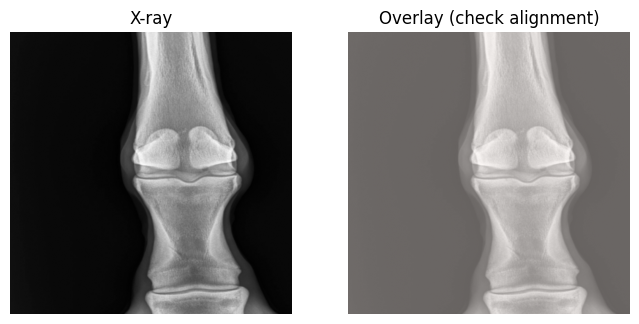

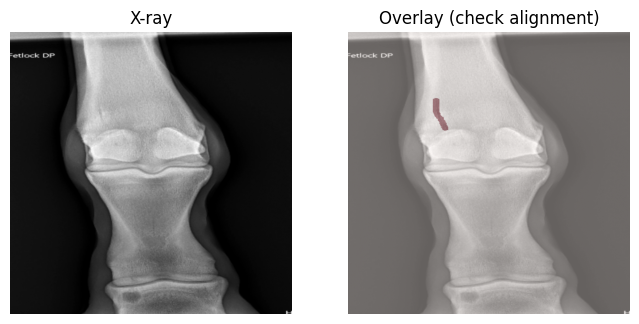

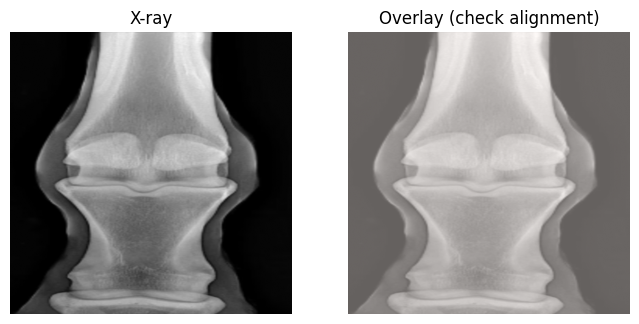

In [ ]:
import os
import glob
import numpy as np
from PIL import Image
import SimpleITK as sitk
import matplotlib.pyplot as plt

# ==== PATHS ====
IMG_DIR = "/content/drive/MyDrive/RVC- Fracture Detection DP/DP"
MASK_DIR = "/content/drive/MyDrive/RVC- Fracture Detection DP/DP Seg"

# ==== LOAD FILENAMES ====
image_files = sorted(glob.glob(os.path.join(IMG_DIR, "*.png")))
mask_files = sorted(glob.glob(os.path.join(MASK_DIR, "*.nrrd")))

mask_dict = {
    os.path.splitext(os.path.basename(f))[0].replace("Seg", ""): f
    for f in mask_files
}

# ==== TARGET SHAPE ====
TARGET_SIZE = (512, 512)

images_np = []
masks_np = []
labels_np = []

print(f"🩻 Found {len(image_files)} images and {len(mask_files)} masks")

for img_path in image_files:
    base = os.path.splitext(os.path.basename(img_path))[0]

    # --- Load and resize image ---
    img = Image.open(img_path).convert("L")
    img = img.resize(TARGET_SIZE, Image.BILINEAR)
    img_np = np.array(img, dtype=np.float32) / 255.0  # normalize to [0, 1]

    # --- Load and resize mask if exists ---
    if base in mask_dict:
        mask_path = mask_dict[base]

        # ✅ Use SimpleITK for correct orientation
        mask_itk = sitk.ReadImage(mask_path)
        mask_np = sitk.GetArrayFromImage(mask_itk)
        mask_np = np.squeeze(mask_np).astype(np.float32)

        # Sometimes SimpleITK loads masks as (1, H, W)
        if mask_np.ndim == 3:
            mask_np = mask_np[0]

        # Ensure mask orientation matches X-ray
        # Flip horizontally if still mirrored
        # mask_np = np.flip(mask_np, axis=1)  # uncomment if needed after visual check

        mask_img = Image.fromarray(mask_np)
        mask_img = mask_img.resize(TARGET_SIZE, Image.NEAREST)
        mask_np = np.array(mask_img, dtype=np.float32)

        label = 1  # fractured
    else:
        mask_np = np.zeros(TARGET_SIZE, dtype=np.float32)
        label = 0  # healthy

    images_np.append(img_np)
    masks_np.append(mask_np)
    labels_np.append(label)

# ==== Convert to numpy arrays ====
images_np = np.stack(images_np, axis=0)
masks_np = np.stack(masks_np, axis=0)
labels_np = np.array(labels_np, dtype=np.int32)

print(f"\n✅ Loaded {len(images_np)} samples")
print(f"Images: {images_np.shape} | Masks: {masks_np.shape} | Labels: {labels_np.shape}")
print(f"Fractured: {np.sum(labels_np)} | Healthy: {len(labels_np) - np.sum(labels_np)}")

# ==== Quick overlay check (visual sanity test) ====
def show_overlay(idx):
    img = images_np[idx]
    mask = masks_np[idx]
    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1)
    plt.imshow(img, cmap="gray")
    plt.title("X-ray")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(img, cmap="gray")
    plt.imshow(mask, cmap="Reds", alpha=0.4)
    plt.title("Overlay (check alignment)")
    plt.axis("off")
    plt.show()

# 👉 Try this on a few samples:
show_overlay(0)
show_overlay(10)
show_overlay(20)


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
Epoch 1/2: 100%|██████████| 45/45 [00:02<00:00, 21.33it/s]


Epoch 1 | Avg loss: 1.6334


Epoch 2/2: 100%|██████████| 45/45 [00:00<00:00, 91.97it/s]


Epoch 2 | Avg loss: 1.5446


Epoch 3/2: 100%|██████████| 45/45 [00:00<00:00, 91.42it/s]


...

Epoch 98 | Avg loss: 0.5879


Epoch 99/2: 100%|██████████| 45/45 [00:00<00:00, 87.09it/s]


Epoch 99 | Avg loss: 0.5764


Epoch 100/2: 100%|██████████| 45/45 [00:00<00:00, 86.99it/s]


Epoch 100 | Avg loss: 0.5865
✅ Forward and training loop ran successfully!


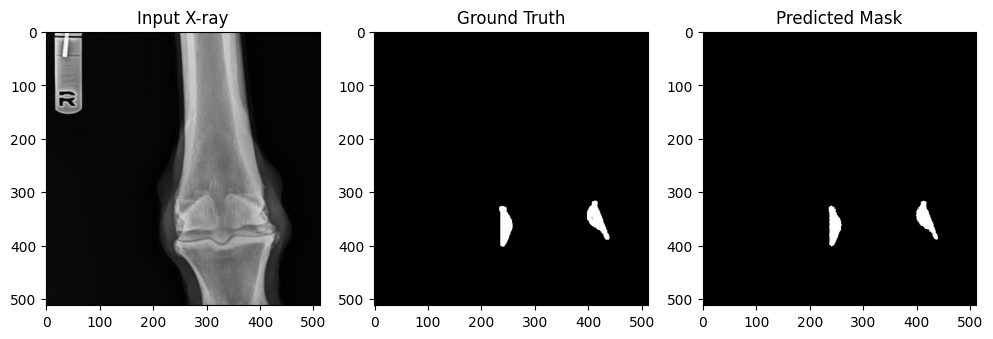

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt
from monai.networks.nets import UNet, BasicUNet
from monai.losses import DiceCELoss

# ========= Dataset =========
class FractureDataset(Dataset):
    def __init__(self, images_np, masks_np):
        self.images = images_np
        self.masks = masks_np

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = torch.tensor(self.images[idx], dtype=torch.float32).unsqueeze(0)
        mask = torch.tensor(self.masks[idx], dtype=torch.float32).unsqueeze(0)
        return img, mask

# ========= Data loaders =========
dataset = FractureDataset(images_np, masks_np)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_set, val_set = random_split(dataset, [train_size, val_size])
train_loader = DataLoader(train_set, batch_size=2, shuffle=True)
val_loader = DataLoader(val_set, batch_size=1)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ========= Choose model =========
# Simple UNet (no pretrained backbone)
model = UNet(
    spatial_dims=2,
    in_channels=1,
    out_channels=1,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
).to(DEVICE)

# ========= Loss & Optimizer =========
criterion = DiceCELoss(sigmoid=True, squared_pred=True)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# ========= Quick Training =========
for epoch in range(100):
    model.train()
    total_loss = 0
    for imgs, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/2"):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        preds = model(imgs)
        preds = torch.nn.functional.interpolate(preds, size=masks.shape[-2:], mode="bilinear", align_corners=False)
        loss = criterion(preds, masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1} | Avg loss: {total_loss/len(train_loader):.4f}")

print("✅ Forward and training loop ran successfully!")

# ========= Test a sample prediction =========
model.eval()
with torch.no_grad():
    img, mask = dataset[3]
    pred = torch.sigmoid(model(img.unsqueeze(0).to(DEVICE))).cpu().squeeze().numpy()

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(img.squeeze(), cmap='gray'); plt.title("Input X-ray")
plt.subplot(1,3,2); plt.imshow(mask.squeeze(), cmap='gray'); plt.title("Ground Truth")
plt.subplot(1,3,3); plt.imshow(pred>0.5, cmap='gray'); plt.title("Predicted Mask")
plt.show()

In [ ]:
torch.save(model.state_dict(), '/content/drive/MyDrive/RVC- Fracture Detection DP/best_simple_unet.pth')
print("✅ Model saved to Drive")

✅ Model saved to Drive


✅ Model loaded
✅ 23 validation samples
  Online74  Dice=0.936
  REH-31-DP-Front-IM-0071-0001  Dice=0.000
  REH-1-DP-Hind-IM-0007-0001  Dice=0.000
  REH-1-Flexed-PD-Hind-IM-0006-0001  Dice=0.852
  Online52  Dice=0.922
  Online106  Dice=0.958
  Online77  Dice=0.862
  REH-7-DP-Front-IM-0114-0001  Dice=0.954
  Online26  Dice=0.888
  Online32  Dice=0.952
  RVCXR29  Dice=0.992

Chosen cases: ['RVCXR29', 'Online106', 'REH-7-DP-Front-IM-0114-0001', 'Online32']


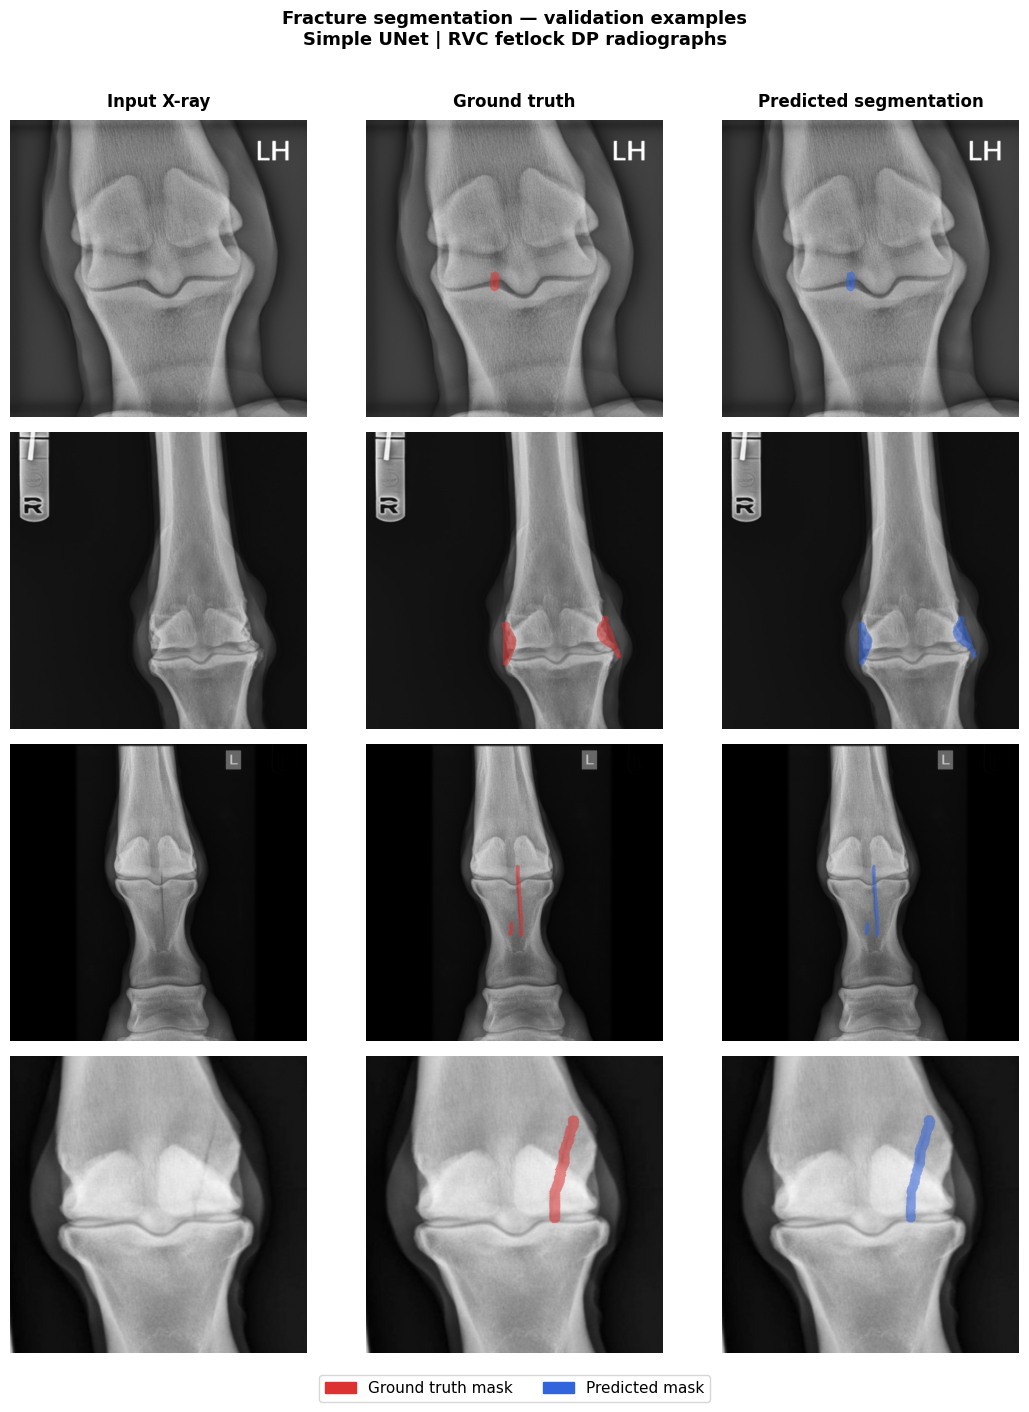

✅ Combined figure saved
  Case 1 saved — RVCXR29  Dice=0.992
  Case 2 saved — Online106  Dice=0.958
  Case 3 saved — REH-7-DP-Front-IM-0114-0001  Dice=0.954
  Case 4 saved — Online32  Dice=0.952

🎉 All figures saved to: /content/drive/MyDrive/RVC- Fracture Detection DP/segmentation_figures


In [ ]:
from monai.networks.nets import UNet
from monai.metrics import DiceMetric
import os, glob, numpy as np, torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import SimpleITK as sitk
from torch.utils.data import Dataset, DataLoader, random_split

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# ── 1. Reload model ───────────────────────────────────────────────────────────
model = UNet(
    spatial_dims=2, in_channels=1, out_channels=1,
    channels=(16, 32, 64, 128, 256), strides=(2, 2, 2, 2),
).to(DEVICE)

model.load_state_dict(torch.load(
    '/content/drive/MyDrive/RVC- Fracture Detection DP/best_simple_unet.pth'))
model.eval()
print("✅ Model loaded")

# ── 2. Reload data ────────────────────────────────────────────────────────────
IMG_DIR  = "/content/drive/MyDrive/RVC- Fracture Detection DP/DP"
MASK_DIR = "/content/drive/MyDrive/RVC- Fracture Detection DP/DP Seg"

image_files = sorted(glob.glob(os.path.join(IMG_DIR,  "*.png")))
mask_files  = sorted(glob.glob(os.path.join(MASK_DIR, "*.nrrd")))
mask_dict   = {os.path.splitext(os.path.basename(f))[0].replace("Seg", ""): f
               for f in mask_files}

images_np, masks_np, basenames = [], [], []
for img_path in image_files:
    base    = os.path.splitext(os.path.basename(img_path))[0]
    img_np  = np.array(Image.open(img_path).convert("L").resize((512,512),
              Image.BILINEAR), dtype=np.float32) / 255.0
    if base in mask_dict:
        m = sitk.GetArrayFromImage(sitk.ReadImage(mask_dict[base]))
        m = np.squeeze(m).astype(np.float32)
        if m.ndim == 3: m = m[0]
        m = np.array(Image.fromarray(m).resize((512,512), Image.NEAREST), dtype=np.float32)
    else:
        m = np.zeros((512,512), dtype=np.float32)
    images_np.append(img_np); masks_np.append(m); basenames.append(base)

images_np = np.stack(images_np)
masks_np  = np.stack(masks_np)

class FractureDataset(Dataset):
    def __init__(self, images, masks, names):
        self.images, self.masks, self.names = images, masks, names
    def __len__(self): return len(self.images)
    def __getitem__(self, idx):
        img  = torch.tensor(self.images[idx], dtype=torch.float32).unsqueeze(0)
        mask = torch.tensor(self.masks[idx],  dtype=torch.float32).unsqueeze(0)
        return img, mask, self.names[idx]

dataset    = FractureDataset(images_np, masks_np, basenames)
train_size = int(0.8 * len(dataset))
val_size   = len(dataset) - train_size
_, val_set = random_split(dataset, [train_size, val_size],
                           generator=torch.Generator().manual_seed(42))
print(f"✅ {val_size} validation samples")

# ── 3. Predict helper ─────────────────────────────────────────────────────────
def predict(img_tensor):
    with torch.no_grad():
        pred = torch.sigmoid(model(img_tensor.unsqueeze(0).to(DEVICE)))
        pred = torch.nn.functional.interpolate(
            pred, size=img_tensor.shape[-2:], mode='bilinear', align_corners=False)
    return pred.cpu().squeeze().numpy()

# ── 4. Pick best cases to show ────────────────────────────────────────────────
# score every val case by dice — pick top 4 with actual masks
scores = []
for i in range(len(val_set)):
    img, mask, name = val_set[i]
    if mask.sum() == 0:
        scores.append((i, -1, name))
        continue
    pred  = predict(img)
    pb    = (pred > 0.5).astype(float)
    mn    = mask.squeeze().numpy()
    dice  = 2*(pb*mn).sum() / (pb.sum()+mn.sum()+1e-8)
    scores.append((i, dice, name))
    print(f"  {name}  Dice={dice:.3f}")

# sort by dice descending, take top 4 with masks
with_mask = [(i,d,n) for i,d,n in scores if d >= 0]
with_mask.sort(key=lambda x: -x[1])
chosen = with_mask[:4]
print(f"\nChosen cases: {[n for _,_,n in chosen]}")

# ── 5. Combined 4-row grant figure ────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from PIL import Image
import os

SAVE_DIR = '/content/drive/MyDrive/RVC- Fracture Detection DP/segmentation_figures'
os.makedirs(SAVE_DIR, exist_ok=True)

def to_rgb(img_np):
    """Convert grayscale [0,1] array to RGB uint8 for coloured overlay."""
    img_uint8 = (img_np * 255).astype(np.uint8)
    return np.stack([img_uint8]*3, axis=-1)

def overlay_mask(img_np, mask_np, color, alpha=0.55):
    """Blend a binary mask onto an RGB image in a given colour."""
    rgb = to_rgb(img_np).astype(float)
    # colour: tuple e.g. (220, 50, 50) for red, (50, 100, 220) for blue
    for c, val in enumerate(color):
        rgb[:,:,c] = np.where(mask_np >= 0.5,
                               (1 - alpha) * rgb[:,:,c] + alpha * val,
                               rgb[:,:,c])
    return rgb.astype(np.uint8)

# ── combined 4-row figure ─────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 3, figsize=(11, 14))
fig.patch.set_facecolor('white')

for col, title in enumerate(['Input X-ray', 'Ground truth', 'Predicted segmentation']):
    axes[0][col].set_title(title, fontsize=12, fontweight='bold', pad=10)

for row, (idx, dice, name) in enumerate(chosen):
    img, mask, _ = val_set[idx]
    pred         = predict(img)
    pred_binary  = (pred > 0.5).astype(float)
    img_np       = img.squeeze().numpy()
    mask_np      = mask.squeeze().numpy()

    # col 0: plain grayscale
    axes[row][0].imshow(img_np, cmap='gray', vmin=0, vmax=1)
    axes[row][0].axis('off')
    axes[row][0].set_ylabel(f'Case {row+1}', fontsize=10,
                             rotation=0, labelpad=40, va='center')

    # col 1: ground truth — red overlay on RGB
    gt_rgb = overlay_mask(img_np, mask_np, color=(220, 50, 50), alpha=0.55)
    axes[row][1].imshow(gt_rgb)
    axes[row][1].axis('off')

    # col 2: prediction — blue overlay on RGB
    pred_rgb = overlay_mask(img_np, pred_binary, color=(50, 100, 220), alpha=0.55)
    axes[row][2].imshow(pred_rgb)
    axes[row][2].set_xlabel(f'Dice = {dice:.2f}', fontsize=10)
    axes[row][2].axis('off')

red_patch  = mpatches.Patch(color=(220/255, 50/255, 50/255),  label='Ground truth mask')
blue_patch = mpatches.Patch(color=(50/255, 100/255, 220/255), label='Predicted mask')
fig.legend(handles=[red_patch, blue_patch], loc='lower center',
           ncol=2, fontsize=11, frameon=True, bbox_to_anchor=(0.5, 0.01))

plt.suptitle('Fracture segmentation — validation examples\n'
             'Simple UNet | RVC fetlock DP radiographs',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(os.path.join(SAVE_DIR, 'Figure2_segmentation.png'),
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Combined figure saved")

# ── individual panels ─────────────────────────────────────────────────────────
for row, (idx, dice, name) in enumerate(chosen):
    img, mask, _ = val_set[idx]
    pred         = predict(img)
    pred_binary  = (pred > 0.5).astype(float)
    img_np       = img.squeeze().numpy()
    mask_np      = mask.squeeze().numpy()

    gt_rgb   = overlay_mask(img_np, mask_np,    color=(220, 50, 50),  alpha=0.55)
    pred_rgb = overlay_mask(img_np, pred_binary, color=(50, 100, 220), alpha=0.55)

    fig2, ax = plt.subplots(1, 3, figsize=(11, 3.5))
    fig2.patch.set_facecolor('white')
    ax[0].imshow(img_np, cmap='gray', vmin=0, vmax=1)
    ax[0].axis('off'); ax[0].set_title('Input X-ray', fontweight='bold')
    ax[1].imshow(gt_rgb)
    ax[1].axis('off'); ax[1].set_title('Ground truth', fontweight='bold')
    ax[2].imshow(pred_rgb)
    ax[2].axis('off'); ax[2].set_title(f'Prediction  (Dice = {dice:.2f})', fontweight='bold')
    plt.tight_layout()
    p = os.path.join(SAVE_DIR, f'case_{row+1}_{name}_segmentation.png')
    plt.savefig(p, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()
    print(f"  Case {row+1} saved — {name}  Dice={dice:.3f}")

print(f"\n🎉 All figures saved to: {SAVE_DIR}")

#Model 5.1


In [ ]:
import os
import glob
import numpy as np
from PIL import Image
import SimpleITK as sitk
import matplotlib.pyplot as plt

# ==== PATHS ====
IMG_DIR = "/content/drive/MyDrive/RVC- Fracture Detection DP/DP"
MASK_DIR = "/content/drive/MyDrive/RVC- Fracture Detection DP/DP Seg"

# ==== LOAD FILENAMES ====
image_files = sorted(glob.glob(os.path.join(IMG_DIR, "*.png")))
mask_files = sorted(glob.glob(os.path.join(MASK_DIR, "*.nrrd")))

mask_dict = {
    os.path.splitext(os.path.basename(f))[0].replace("Seg", ""): f
    for f in mask_files
}

# ==== TARGET SHAPE ====
TARGET_SIZE = (512, 512)

images_np = []
masks_np = []
labels_np = []

print(f"🩻 Found {len(image_files)} images and {len(mask_files)} masks")

for img_path in image_files:
    base = os.path.splitext(os.path.basename(img_path))[0]

    # --- Load and resize image ---
    img = Image.open(img_path).convert("L")
    img = img.resize(TARGET_SIZE, Image.BILINEAR)
    img_np = np.array(img, dtype=np.float32) / 255.0  # normalize to [0, 1]

    # --- Load and resize mask if exists ---
    if base in mask_dict:
        mask_path = mask_dict[base]

        # ✅ Use SimpleITK for correct orientation
        mask_itk = sitk.ReadImage(mask_path)
        mask_np = sitk.GetArrayFromImage(mask_itk)
        mask_np = np.squeeze(mask_np).astype(np.float32)

        # Sometimes SimpleITK loads masks as (1, H, W)
        if mask_np.ndim == 3:
            mask_np = mask_np[0]

        # Ensure mask orientation matches X-ray
        # Flip horizontally if still mirrored
        # mask_np = np.flip(mask_np, axis=1)  # uncomment if needed after visual check

        mask_img = Image.fromarray(mask_np)
        mask_img = mask_img.resize(TARGET_SIZE, Image.NEAREST)
        mask_np = np.array(mask_img, dtype=np.float32)

        label = 1  # fractured
    else:
        mask_np = np.zeros(TARGET_SIZE, dtype=np.float32)
        label = 0  # healthy

    images_np.append(img_np)
    masks_np.append(mask_np)
    labels_np.append(label)

# ==== Convert to numpy arrays ====
images_np = np.stack(images_np, axis=0)
masks_np = np.stack(masks_np, axis=0)
labels_np = np.array(labels_np, dtype=np.int32)

print(f"\n✅ Loaded {len(images_np)} samples")
print(f"Images: {images_np.shape} | Masks: {masks_np.shape} | Labels: {labels_np.shape}")
print(f"Fractured: {np.sum(labels_np)} | Healthy: {len(labels_np) - np.sum(labels_np)}")

# ==== Quick overlay check (visual sanity test) ====
def show_overlay(idx):
    img = images_np[idx]
    mask = masks_np[idx]
    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1)
    plt.imshow(img, cmap="gray")
    plt.title("X-ray")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(img, cmap="gray")
    plt.imshow(mask, cmap="Reds", alpha=0.4)
    plt.title("Overlay (check alignment)")
    plt.axis("off")
    plt.show()

# 👉 Try this on a few samples:
show_overlay(0)
show_overlay(10)
show_overlay(20)


Device: cuda


Epoch 1/20: 100%|██████████| 17/17 [00:00<00:00, 47.68it/s]


Epoch 1/20 | Total loss: 1.5925


Epoch 2/20: 100%|██████████| 17/17 [00:00<00:00, 47.60it/s]


Epoch 2/20 | Total loss: 1.5357


...

Epoch 18/20 | Total loss: 1.2700


Epoch 19/20: 100%|██████████| 17/17 [00:00<00:00, 47.01it/s]


Epoch 19/20 | Total loss: 1.2585


Epoch 20/20: 100%|██████████| 17/17 [00:00<00:00, 48.62it/s]


Epoch 20/20 | Total loss: 1.2472
✅ Mean Teacher training complete.


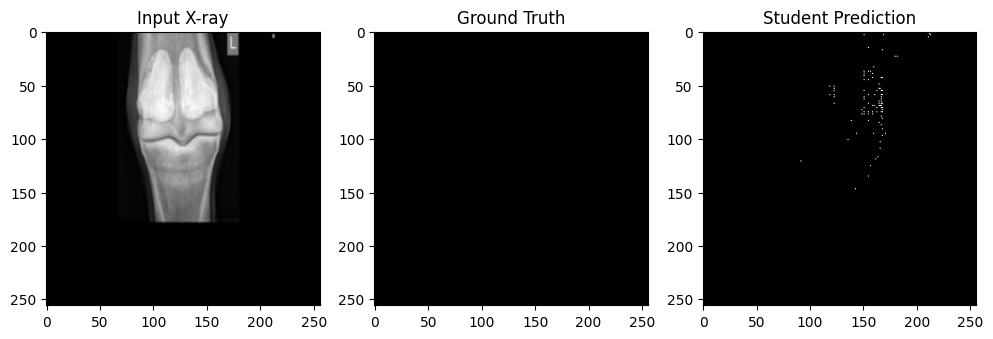

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import Dataset, DataLoader, random_split
from monai.networks.nets import UNet
from monai.losses import DiceCELoss
from tqdm import tqdm
import matplotlib.pyplot as plt
from torchvision.transforms.functional import resize

# ======================================
# Dataset: labelled & unlabelled splits
# ======================================
class FractureDataset(Dataset):
    def __init__(self, images_np, masks_np, target_size=256, labelled=True):
        self.images = images_np
        self.masks = masks_np
        self.labelled = labelled
        self.target_size = target_size

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        img = torch.tensor(img, dtype=torch.float32).unsqueeze(0)
        img = resize(img, [self.target_size, self.target_size])

        if self.labelled:
            mask = self.masks[idx]
            if np.isscalar(mask) or mask.ndim < 2:
                mask = np.zeros((512, 512), dtype=np.float32)
            mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)
            mask = resize(mask, [self.target_size, self.target_size])
        else:
            mask = torch.zeros((1, self.target_size, self.target_size))  # dummy

        return img, mask


# ======================================
# Model
# ======================================
def get_unet():
    return UNet(
        spatial_dims=2,
        in_channels=1,
        out_channels=1,
        channels=(16, 32, 64, 128, 256),
        strides=(2, 2, 2, 2)
    )


# ======================================
# Mean Teacher training loop
# ======================================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

# Split labelled vs unlabelled (e.g., 30% have masks)
# label_indices = np.where(np.sum(masks_np, axis=(1, 2)) > 0)[0]
# unlabel_indices = np.where(np.sum(masks_np, axis=(1, 2)) == 0)[0]

# Split dataset 30/70 into labelled and unlabelled subsets
num_samples = len(images_np)
all_indices = np.arange(num_samples)
np.random.shuffle(all_indices)

split_point = int(0.3 * num_samples)
label_indices = all_indices[:split_point]
unlabel_indices = all_indices[split_point:]

labelled_images = images_np[label_indices]
labelled_masks = masks_np[label_indices]
unlabelled_images = images_np[unlabel_indices]
unlabelled_masks = masks_np[unlabel_indices]  # zeros

label_ds = FractureDataset(labelled_images, labelled_masks, labelled=True)
unlabel_ds = FractureDataset(unlabelled_images, unlabelled_masks, labelled=False)

label_loader = DataLoader(label_ds, batch_size=2, shuffle=True)
unlabel_loader = DataLoader(unlabel_ds, batch_size=2, shuffle=True)

# Create student & teacher models
student = get_unet().to(DEVICE)
teacher = get_unet().to(DEVICE)
teacher.load_state_dict(student.state_dict())
for p in teacher.parameters():
    p.requires_grad = False  # freeze teacher

criterion = DiceCELoss(sigmoid=True, squared_pred=True)
consistency_criterion = nn.MSELoss()
optimizer = optim.Adam(student.parameters(), lr=1e-4)
ema_decay = 0.99
EPOCHS = 20

# ======================================
# Training
# ======================================
for epoch in range(EPOCHS):
    student.train()
    total_loss = 0
    for (img_lab, mask_lab), (img_unlab, _) in zip(tqdm(label_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"), unlabel_loader):
        img_lab, mask_lab = img_lab.to(DEVICE), mask_lab.to(DEVICE)
        img_unlab = img_unlab.to(DEVICE)

        # --- 1. Supervised loss on labelled data ---
        pred_lab = student(img_lab)
        pred_lab = torch.nn.functional.interpolate(pred_lab, size=mask_lab.shape[-2:], mode="bilinear", align_corners=False)
        sup_loss = criterion(pred_lab, mask_lab)

        # --- 2. Consistency loss on unlabelled data ---
        with torch.no_grad():
            teacher_pred = torch.sigmoid(teacher(img_unlab))
        student_pred = torch.sigmoid(student(img_unlab))
        cons_loss = consistency_criterion(student_pred, teacher_pred)

        # --- 3. Total loss ---
        loss = sup_loss + 0.1 * cons_loss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        # --- 4. EMA update teacher weights ---
        with torch.no_grad():
            for t_param, s_param in zip(teacher.parameters(), student.parameters()):
                t_param.data = ema_decay * t_param.data + (1 - ema_decay) * s_param.data

    print(f"Epoch {epoch+1}/{EPOCHS} | Total loss: {total_loss/len(label_loader):.4f}")

print("✅ Mean Teacher training complete.")

# ======================================
# Evaluate on labelled validation set
# ======================================
student.eval()
img, mask = label_ds[2]
with torch.no_grad():
    pred = torch.sigmoid(student(img.unsqueeze(0).to(DEVICE))).cpu().squeeze().numpy()

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(img.squeeze(), cmap='gray'); plt.title("Input X-ray")
plt.subplot(1,3,2); plt.imshow(mask.squeeze(), cmap='gray'); plt.title("Ground Truth")
plt.subplot(1,3,3); plt.imshow(pred>0.5, cmap='gray'); plt.title("Student Prediction")
plt.show()


#Model 6.1
Foundation Model

🩻 Found 112 images and 50 masks

✅ Loaded 112 samples
Images: (112, 512, 512) | Masks: (112, 512, 512) | Labels: (112,)
Fractured: 49 | Healthy: 63


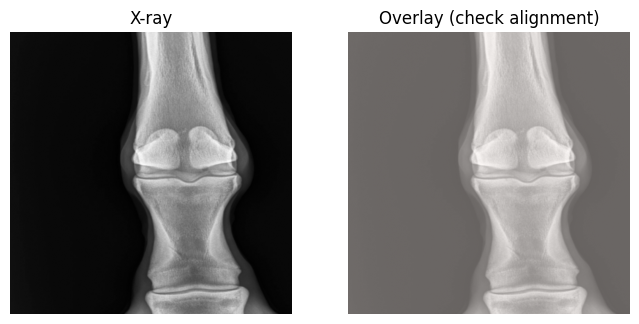

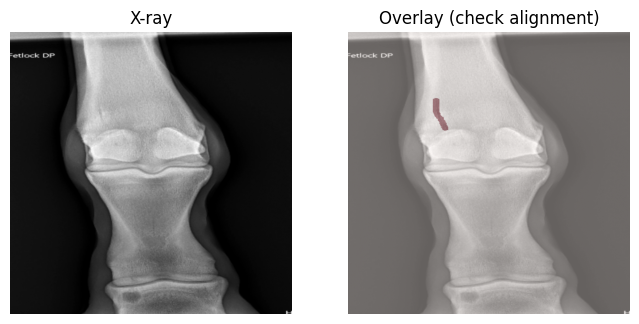

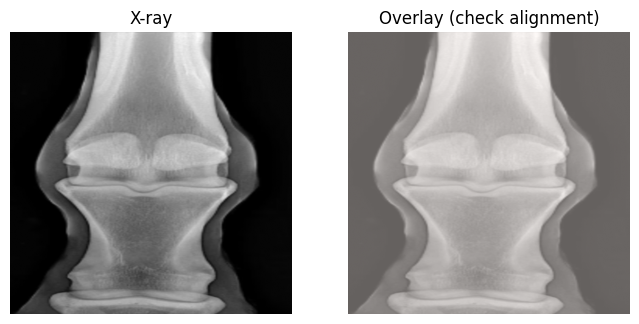

In [ ]:
import os
import glob
import numpy as np
from PIL import Image
import SimpleITK as sitk
import matplotlib.pyplot as plt

# ==== PATHS ====
IMG_DIR = "/content/drive/MyDrive/RVC- Fracture Detection DP/DP"
MASK_DIR = "/content/drive/MyDrive/RVC- Fracture Detection DP/DP Seg"

# ==== LOAD FILENAMES ====
image_files = sorted(glob.glob(os.path.join(IMG_DIR, "*.png")))
mask_files = sorted(glob.glob(os.path.join(MASK_DIR, "*.nrrd")))

mask_dict = {
    os.path.splitext(os.path.basename(f))[0].replace("Seg", ""): f
    for f in mask_files
}

# ==== TARGET SHAPE ====
TARGET_SIZE = (512, 512)

images_np = []
masks_np = []
labels_np = []

print(f"🩻 Found {len(image_files)} images and {len(mask_files)} masks")

for img_path in image_files:
    base = os.path.splitext(os.path.basename(img_path))[0]

    # --- Load and resize image ---
    img = Image.open(img_path).convert("L")
    img = img.resize(TARGET_SIZE, Image.BILINEAR)
    img_np = np.array(img, dtype=np.float32) / 255.0  # normalize to [0, 1]

    # --- Load and resize mask if exists ---
    if base in mask_dict:
        mask_path = mask_dict[base]

        # ✅ Use SimpleITK for correct orientation
        mask_itk = sitk.ReadImage(mask_path)
        mask_np = sitk.GetArrayFromImage(mask_itk)
        mask_np = np.squeeze(mask_np).astype(np.float32)

        # Sometimes SimpleITK loads masks as (1, H, W)
        if mask_np.ndim == 3:
            mask_np = mask_np[0]

        # Ensure mask orientation matches X-ray
        # Flip horizontally if still mirrored
        # mask_np = np.flip(mask_np, axis=1)  # uncomment if needed after visual check

        mask_img = Image.fromarray(mask_np)
        mask_img = mask_img.resize(TARGET_SIZE, Image.NEAREST)
        mask_np = np.array(mask_img, dtype=np.float32)

        label = 1  # fractured
    else:
        mask_np = np.zeros(TARGET_SIZE, dtype=np.float32)
        label = 0  # healthy

    images_np.append(img_np)
    masks_np.append(mask_np)
    labels_np.append(label)

# ==== Convert to numpy arrays ====
images_np = np.stack(images_np, axis=0)
masks_np = np.stack(masks_np, axis=0)
labels_np = np.array(labels_np, dtype=np.int32)

print(f"\n✅ Loaded {len(images_np)} samples")
print(f"Images: {images_np.shape} | Masks: {masks_np.shape} | Labels: {labels_np.shape}")
print(f"Fractured: {np.sum(labels_np)} | Healthy: {len(labels_np) - np.sum(labels_np)}")

# ==== Quick overlay check (visual sanity test) ====
def show_overlay(idx):
    img = images_np[idx]
    mask = masks_np[idx]
    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1)
    plt.imshow(img, cmap="gray")
    plt.title("X-ray")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(img, cmap="gray")
    plt.imshow(mask, cmap="Reds", alpha=0.4)
    plt.title("Overlay (check alignment)")
    plt.axis("off")
    plt.show()

# 👉 Try this on a few samples:
show_overlay(0)
show_overlay(10)
show_overlay(20)


Using device: cuda
✅ Dataset ready — 89 train, 23 val samples
⚠️ Could not load pretrained weights automatically: string indices must be integers, not 'str'
Training from scratch instead.


Epoch 1/100: 100%|██████████| 45/45 [00:03<00:00, 12.24it/s]


Epoch 1/100 | Loss: 1.3421 | Dice: 0.0000


Epoch 2/100: 100%|██████████| 45/45 [00:03<00:00, 12.63it/s]


Epoch 2/100 | Loss: 1.1956 | Dice: 0.0000


...

Epoch 98/100 | Loss: 0.6028 | Dice: 0.0297


Epoch 99/100: 100%|██████████| 45/45 [00:03<00:00, 12.27it/s]


Epoch 99/100 | Loss: 0.5940 | Dice: 0.0288


Epoch 100/100: 100%|██████████| 45/45 [00:03<00:00, 12.29it/s]


Epoch 100/100 | Loss: 0.6054 | Dice: 0.0316
🏁 Training done. Best Dice: 0.0644


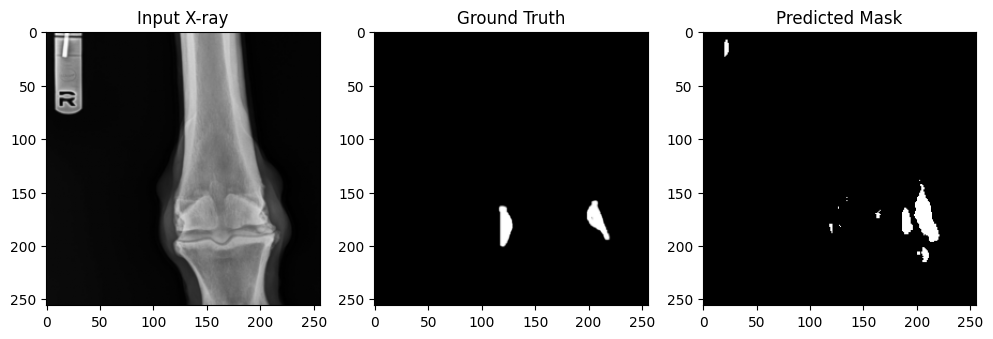

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from monai.networks.nets import SwinUNETR
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from torchvision.transforms.functional import resize

# ======================
# Dataset
# ======================
class FractureDataset(Dataset):
    def __init__(self, images_np, masks_np, target_size=256):
        self.images = images_np
        self.masks = masks_np
        self.target_size = target_size

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        mask = self.masks[idx]

        # enforce 2D shape
        if np.isscalar(mask) or mask.ndim < 2:
            mask = np.zeros((512, 512), dtype=np.float32)
        elif mask.ndim == 3:
            mask = mask.squeeze()

        # convert to tensor
        img = torch.tensor(img, dtype=torch.float32).unsqueeze(0)
        mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)

        # resize both to target size
        img = resize(img, [self.target_size, self.target_size])
        mask = resize(mask, [self.target_size, self.target_size])
        return img, mask


# ======================
# Setup
# ======================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

dataset = FractureDataset(images_np, masks_np, target_size=256)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_set, val_set = random_split(dataset, [train_size, val_size])
train_loader = DataLoader(train_set, batch_size=2, shuffle=True)
val_loader = DataLoader(val_set, batch_size=1)

print(f"✅ Dataset ready — {train_size} train, {val_size} val samples")

# ======================
# Model (Foundation: SwinUNETR)
# ======================
# model = SwinUNETR(
#     spatial_dims=2,
#     in_channels=1,
#     out_channels=1,
#     feature_size=48,
#     use_checkpoint=False,
#     pretrained=True,  # foundation weights
# ).to(DEVICE)

from monai.networks.nets import SwinUNETR

model = SwinUNETR(
    spatial_dims=2,
    in_channels=1,
    out_channels=1,
    feature_size=48,
    use_checkpoint=False,
).to(DEVICE)

# ✅ Load pretrained (foundation) weights
# Available checkpoints from MONAI Model Zoo:
# "swin_unetr.base" is a strong foundation model trained on MSD
try:
    model.load_from("swin_unetr.base")
    print("✅ Loaded MONAI foundation weights (swin_unetr.base).")
except Exception as e:
    print("⚠️ Could not load pretrained weights automatically:", e)
    print("Training from scratch instead.")

criterion = DiceCELoss(sigmoid=True, squared_pred=True)
optimizer = optim.AdamW(model.parameters(), lr=1e-4)
dice_metric = DiceMetric(include_background=False, reduction="mean")

# ======================
# Training Loop
# ======================
best_dice = 0.0
EPOCHS = 100

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for imgs, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)

        preds = model(imgs)
        preds = torch.nn.functional.interpolate(
            preds, size=masks.shape[-2:], mode="bilinear", align_corners=False
        )

        loss = criterion(preds, masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # ===== Validation =====
    model.eval()
    dices = []
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            outputs = torch.sigmoid(model(imgs))
            outputs = torch.nn.functional.interpolate(
                outputs, size=masks.shape[-2:], mode="bilinear", align_corners=False
            )
            preds = (outputs > 0.5).float()
            dice_metric(preds, masks)
            dice_val = dice_metric.aggregate().item()
            dice_metric.reset()
            dices.append(dice_val)

    val_dice = np.mean(dices)
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {total_loss/len(train_loader):.4f} | Dice: {val_dice:.4f}")

    if val_dice > best_dice:
        best_dice = val_dice
        torch.save(model.state_dict(), "best_swinunetr_foundation.pth")
        print("✅ Saved new best model")

print(f"🏁 Training done. Best Dice: {best_dice:.4f}")

# ======================
# Visualize Prediction
# ======================
model.load_state_dict(torch.load("best_swinunetr_foundation.pth"))
model.eval()

img, mask = dataset[3]
with torch.no_grad():
    pred = torch.sigmoid(model(img.unsqueeze(0).to(DEVICE))).cpu().squeeze().numpy()

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(img.squeeze(), cmap="gray"); plt.title("Input X-ray")
plt.subplot(1,3,2); plt.imshow(mask.squeeze(), cmap="gray"); plt.title("Ground Truth")
plt.subplot(1,3,3); plt.imshow(pred>0.5, cmap="gray"); plt.title("Predicted Mask")
plt.show()
